In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading the training dataset
df = pd.read_csv("../data/cs-training.csv")

# Removing the unnamed index column
df = df.drop(columns=["Unnamed: 0"])

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [4]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [5]:
missing = df.isnull().sum()
missing[missing > 0]

MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64

In [6]:
df['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [7]:
df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64

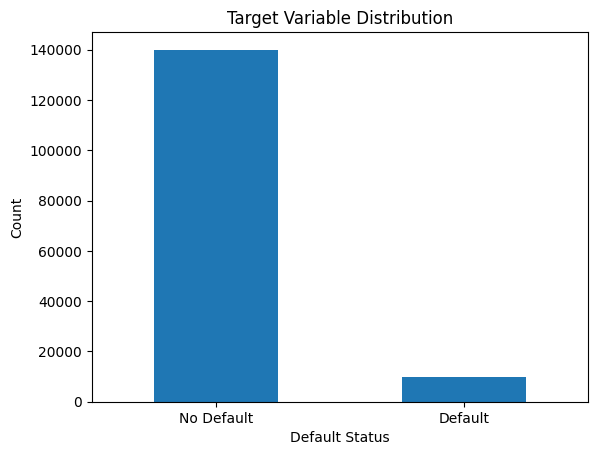

In [8]:
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar')

plt.title("Target Variable Distribution")
plt.xlabel("Default Status")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Default", "Default"], rotation=0)

plt.show()

In [9]:
print("Minimum age:", df['age'].min())
print("Maximum age:", df['age'].max())

Minimum age: 0
Maximum age: 109


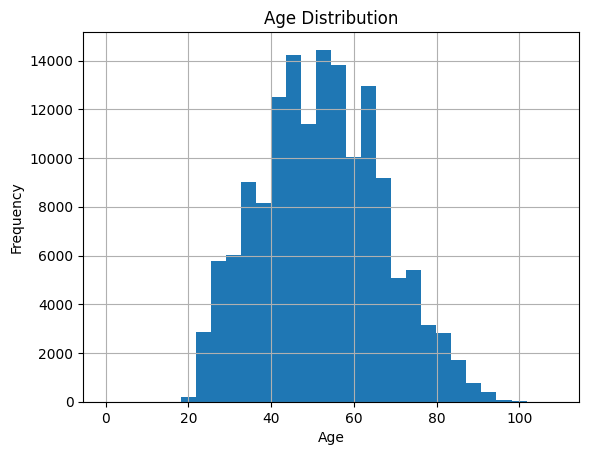

In [10]:
df['age'].hist(bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [11]:
df['DebtRatio'].describe()

count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
25%           0.175074
50%           0.366508
75%           0.868254
max      329664.000000
Name: DebtRatio, dtype: float64

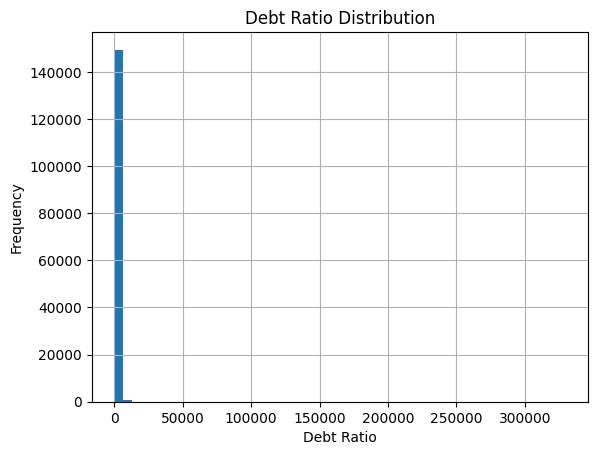

In [12]:
df['DebtRatio'].hist(bins=50)

plt.title("Debt Ratio Distribution")
plt.xlabel("Debt Ratio")
plt.ylabel("Frequency")

plt.show()

In [13]:
df['MonthlyIncome'].describe()

count    1.202690e+05
mean     6.670221e+03
std      1.438467e+04
min      0.000000e+00
25%      3.400000e+03
50%      5.400000e+03
75%      8.249000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

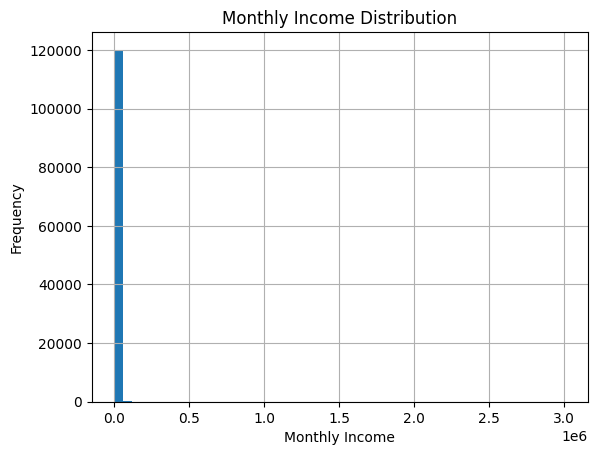

In [14]:
df['MonthlyIncome'].hist(bins=50)

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")

plt.show()

In [15]:
cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

df[cols].describe()

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse
count,150000.000000,150000.000000,150000.000000
mean,0.421033,0.265973,0.240387
std,4.192781,4.169304,4.155179
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,98.000000,98.000000,98.000000


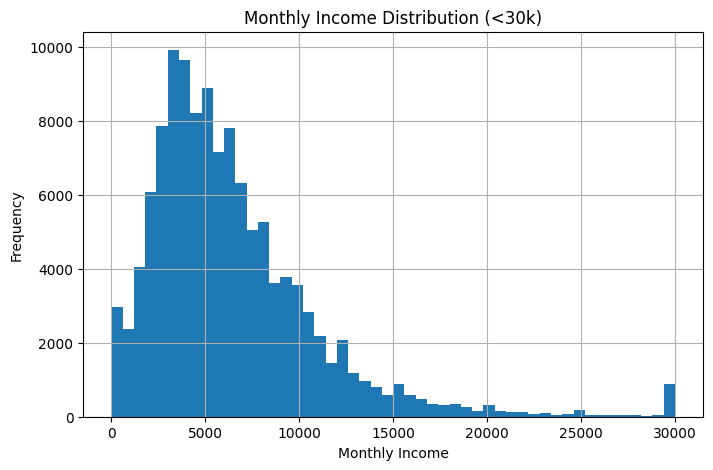

In [16]:
plt.figure(figsize=(8,5))

df['MonthlyIncome'].dropna().clip(upper=30000).hist(bins=50)

plt.title("Monthly Income Distribution (<30k)")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")

plt.show()

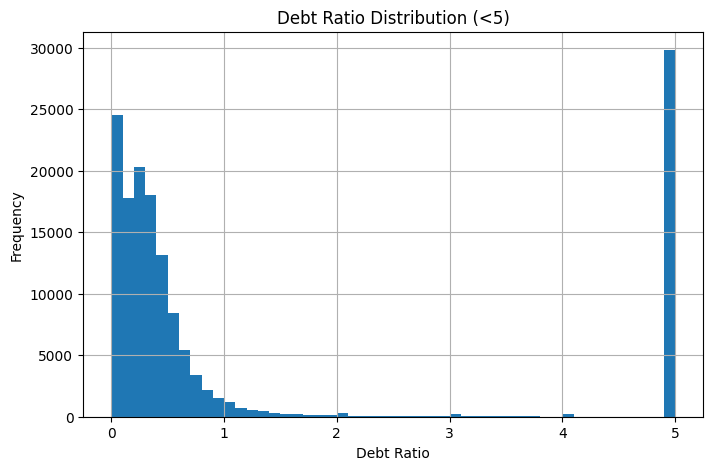

In [17]:
plt.figure(figsize=(8,5))

df['DebtRatio'].clip(upper=5).hist(bins=50)

plt.title("Debt Ratio Distribution (<5)")
plt.xlabel("Debt Ratio")
plt.ylabel("Frequency")

plt.show()

In [18]:
(df['age'] == 0).sum()

1

In [19]:
(df['DebtRatio'] > 5).sum()

29646

In [20]:
(df['MonthlyIncome'] > 30000).sum()

792

In [21]:
df_raw = df.copy()

In [22]:
df_raw.equals(df)

True

In [23]:
df_clean = df_raw.copy()

In [24]:
print("Before:", df_clean.shape)

df_clean = df_clean[df_clean['age'] > 0]

print("After removing age=0:", df_clean.shape)

Before: (150000, 11)
After removing age=0: (149999, 11)


In [25]:
print("Before:", df_clean.shape)

df_clean = df_clean[
    (df_clean['NumberOfTime30-59DaysPastDueNotWorse'] < 96) &
    (df_clean['NumberOfTimes90DaysLate'] < 96) &
    (df_clean['NumberOfTime60-89DaysPastDueNotWorse'] < 96)
]

print("After removing 96/98 anomalies:", df_clean.shape)

Before: (149999, 11)
After removing 96/98 anomalies: (149730, 11)


In [26]:
print(149999-149730)

269


In [27]:
df_clean.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29610
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3893
dtype: int64

In [28]:
income_median = df_clean['MonthlyIncome'].median()
dependents_median = df_clean['NumberOfDependents'].median()

print("Income Median:", income_median)
print("Dependents Median:", dependents_median)

Income Median: 5400.0
Dependents Median: 0.0


In [29]:
income_median = df_clean['MonthlyIncome'].median()
dependents_median = df_clean['NumberOfDependents'].median()

df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(income_median)

df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(dependents_median)

In [30]:
df_clean.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [31]:
import os

os.makedirs("../data/interim", exist_ok=True)

In [32]:
df_clean.to_csv(
    "../data/interim/train_cleaned_v1.csv",
    index=False
)

print("Saved!")

Saved!
